<a href="https://colab.research.google.com/github/Salma5806/balance-sheet-recognition/blob/main/table_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.5/112.6 GB disk)


In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

/content/datasets


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Ii7akICveV5F9RRRngzJ")
project = rf.workspace("table-odbbr").project("finance-vnyzn")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to finance-3 in yolov11:: 100%|██████████| 696/696 [00:00<00:00, 4313.68it/s]


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=50 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 179MB/s]
New https://pypi.org/project/ultralytics/8.3.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/finance-3/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=N

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    train_batch0.jpg
confusion_matrix_normalized.png			    train_batch1.jpg
confusion_matrix.png				    train_batch2.jpg
events.out.tfevents.1747508111.985825baa769.1293.0  train_batch640.jpg
F1_curve.png					    train_batch641.jpg
labels_correlogram.jpg				    train_batch642.jpg
labels.jpg					    val_batch0_labels.jpg
P_curve.png					    val_batch0_pred.jpg
PR_curve.png					    val_batch1_labels.jpg
R_curve.png					    val_batch1_pred.jpg
results.csv					    weights
results.png


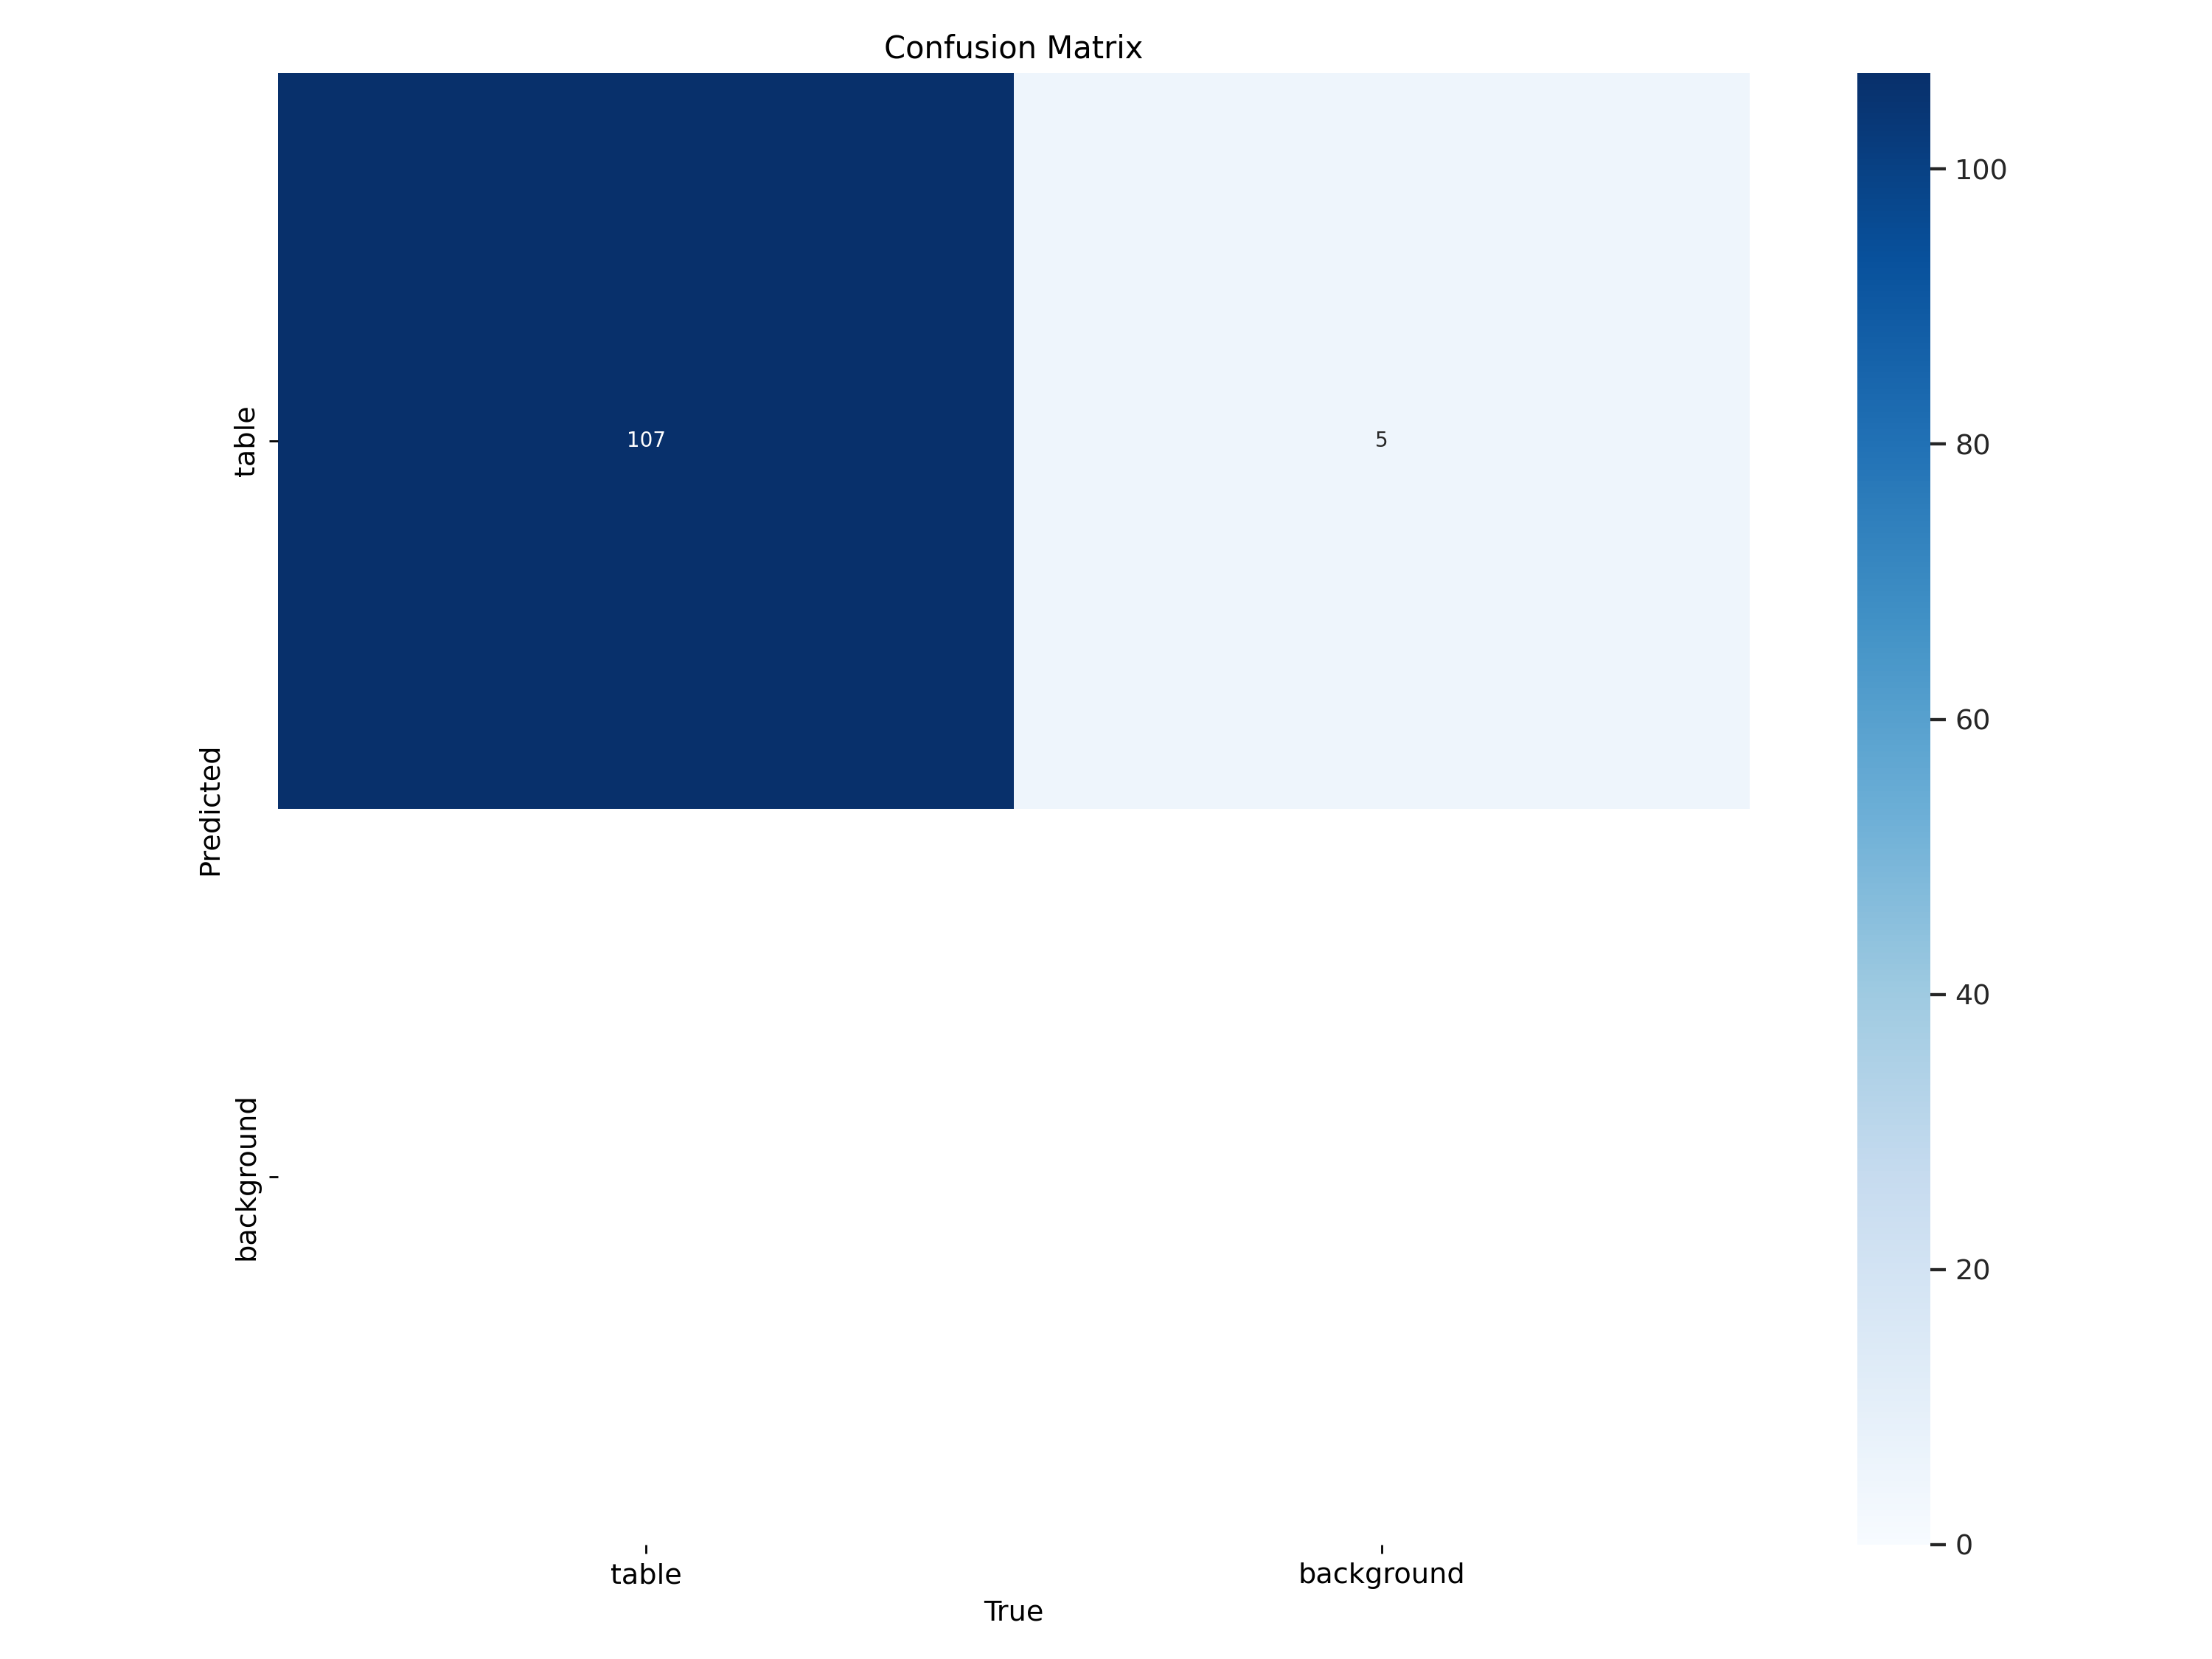

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

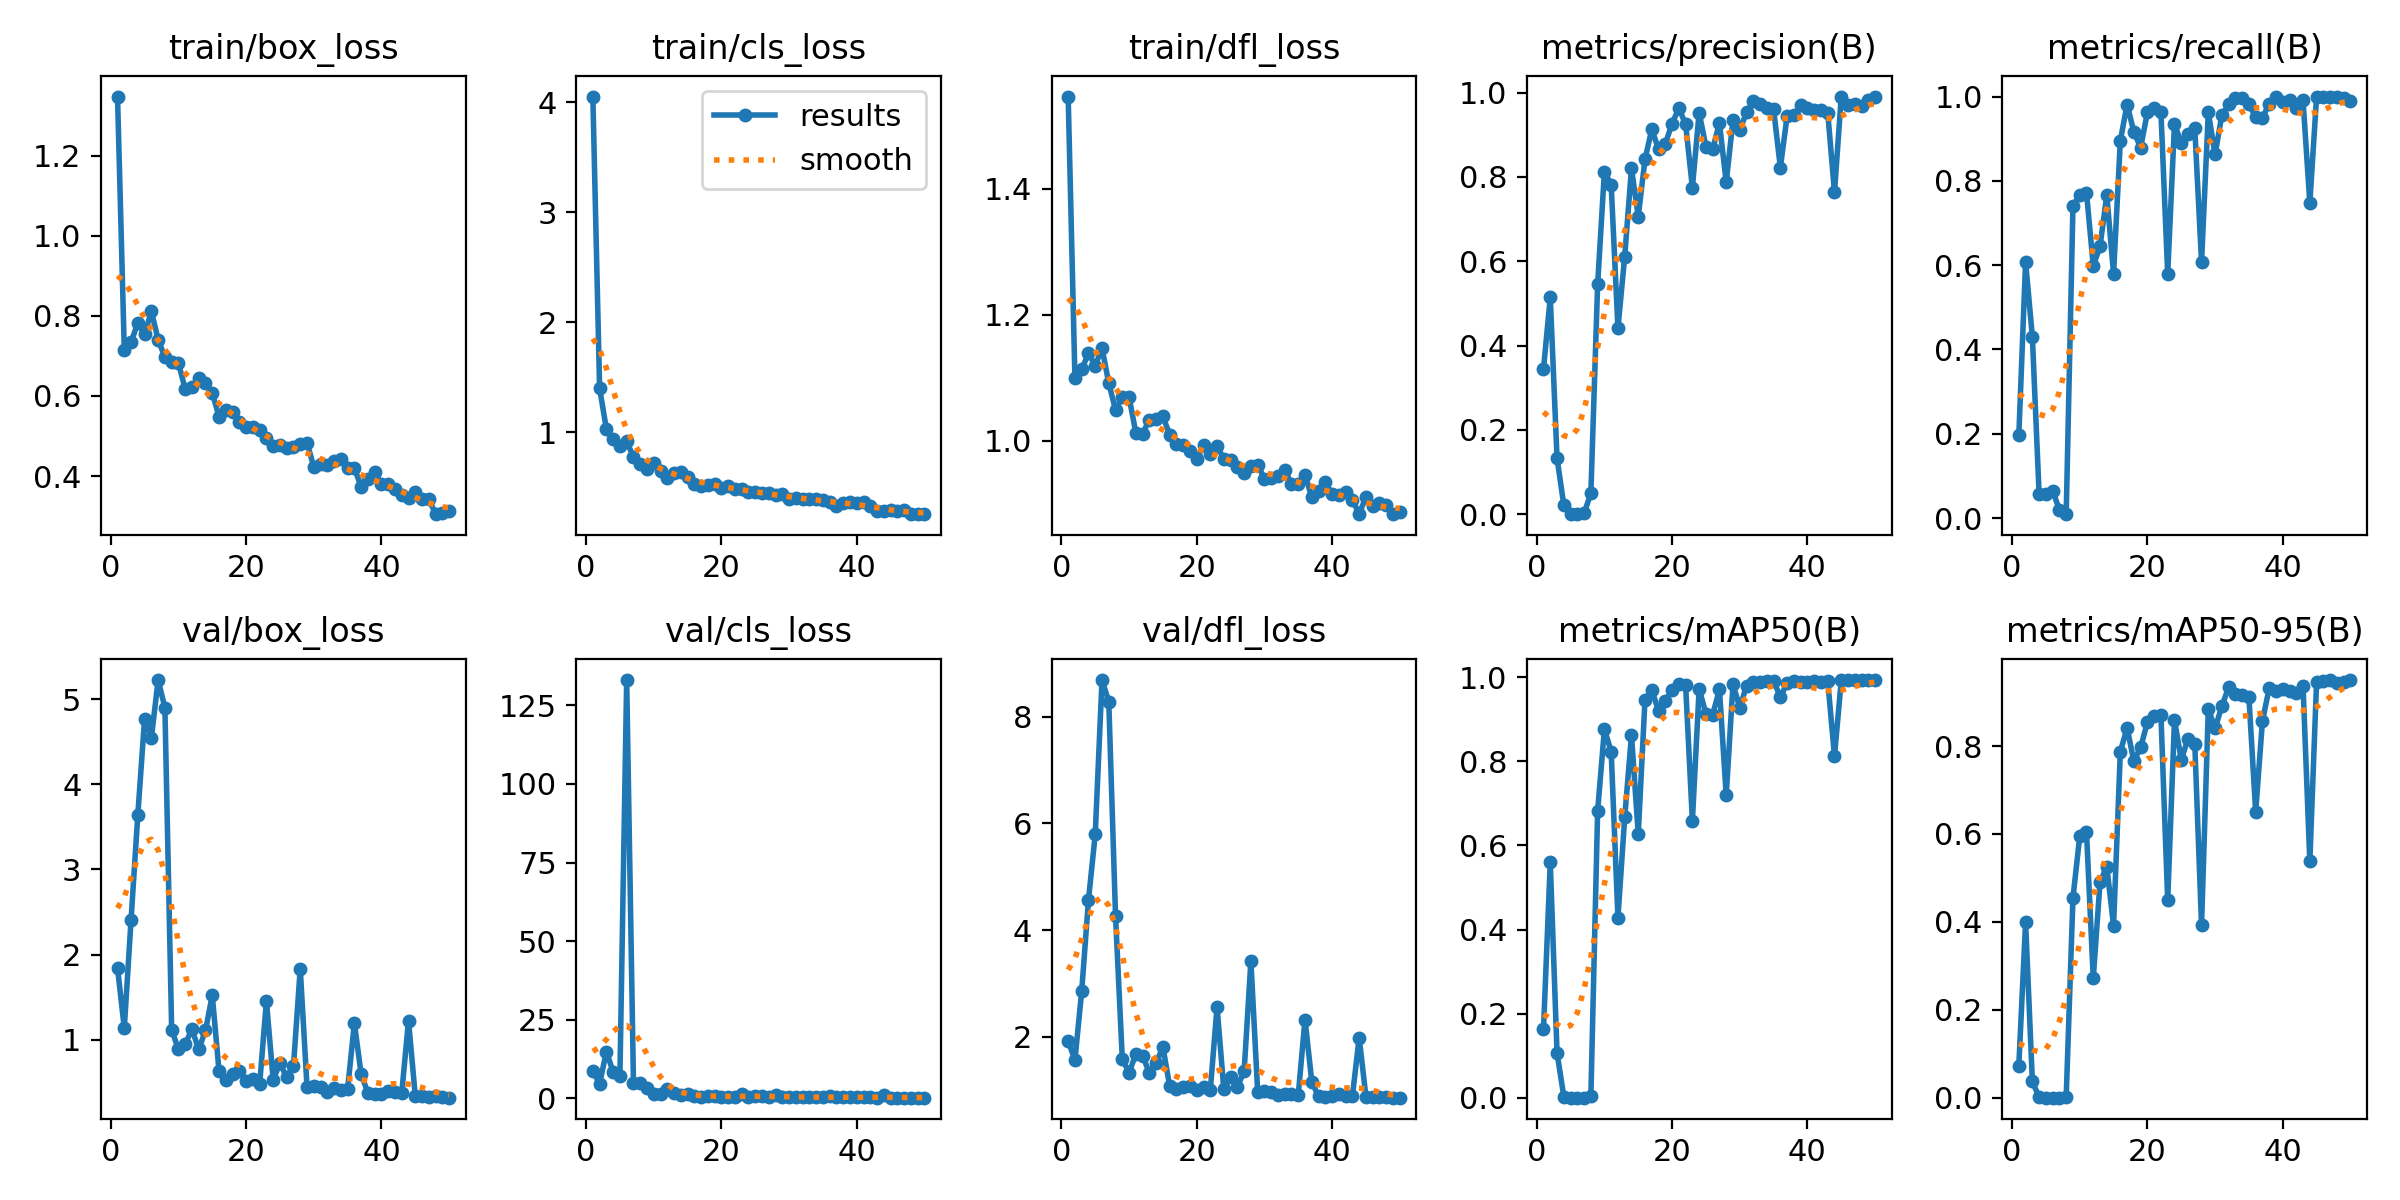

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

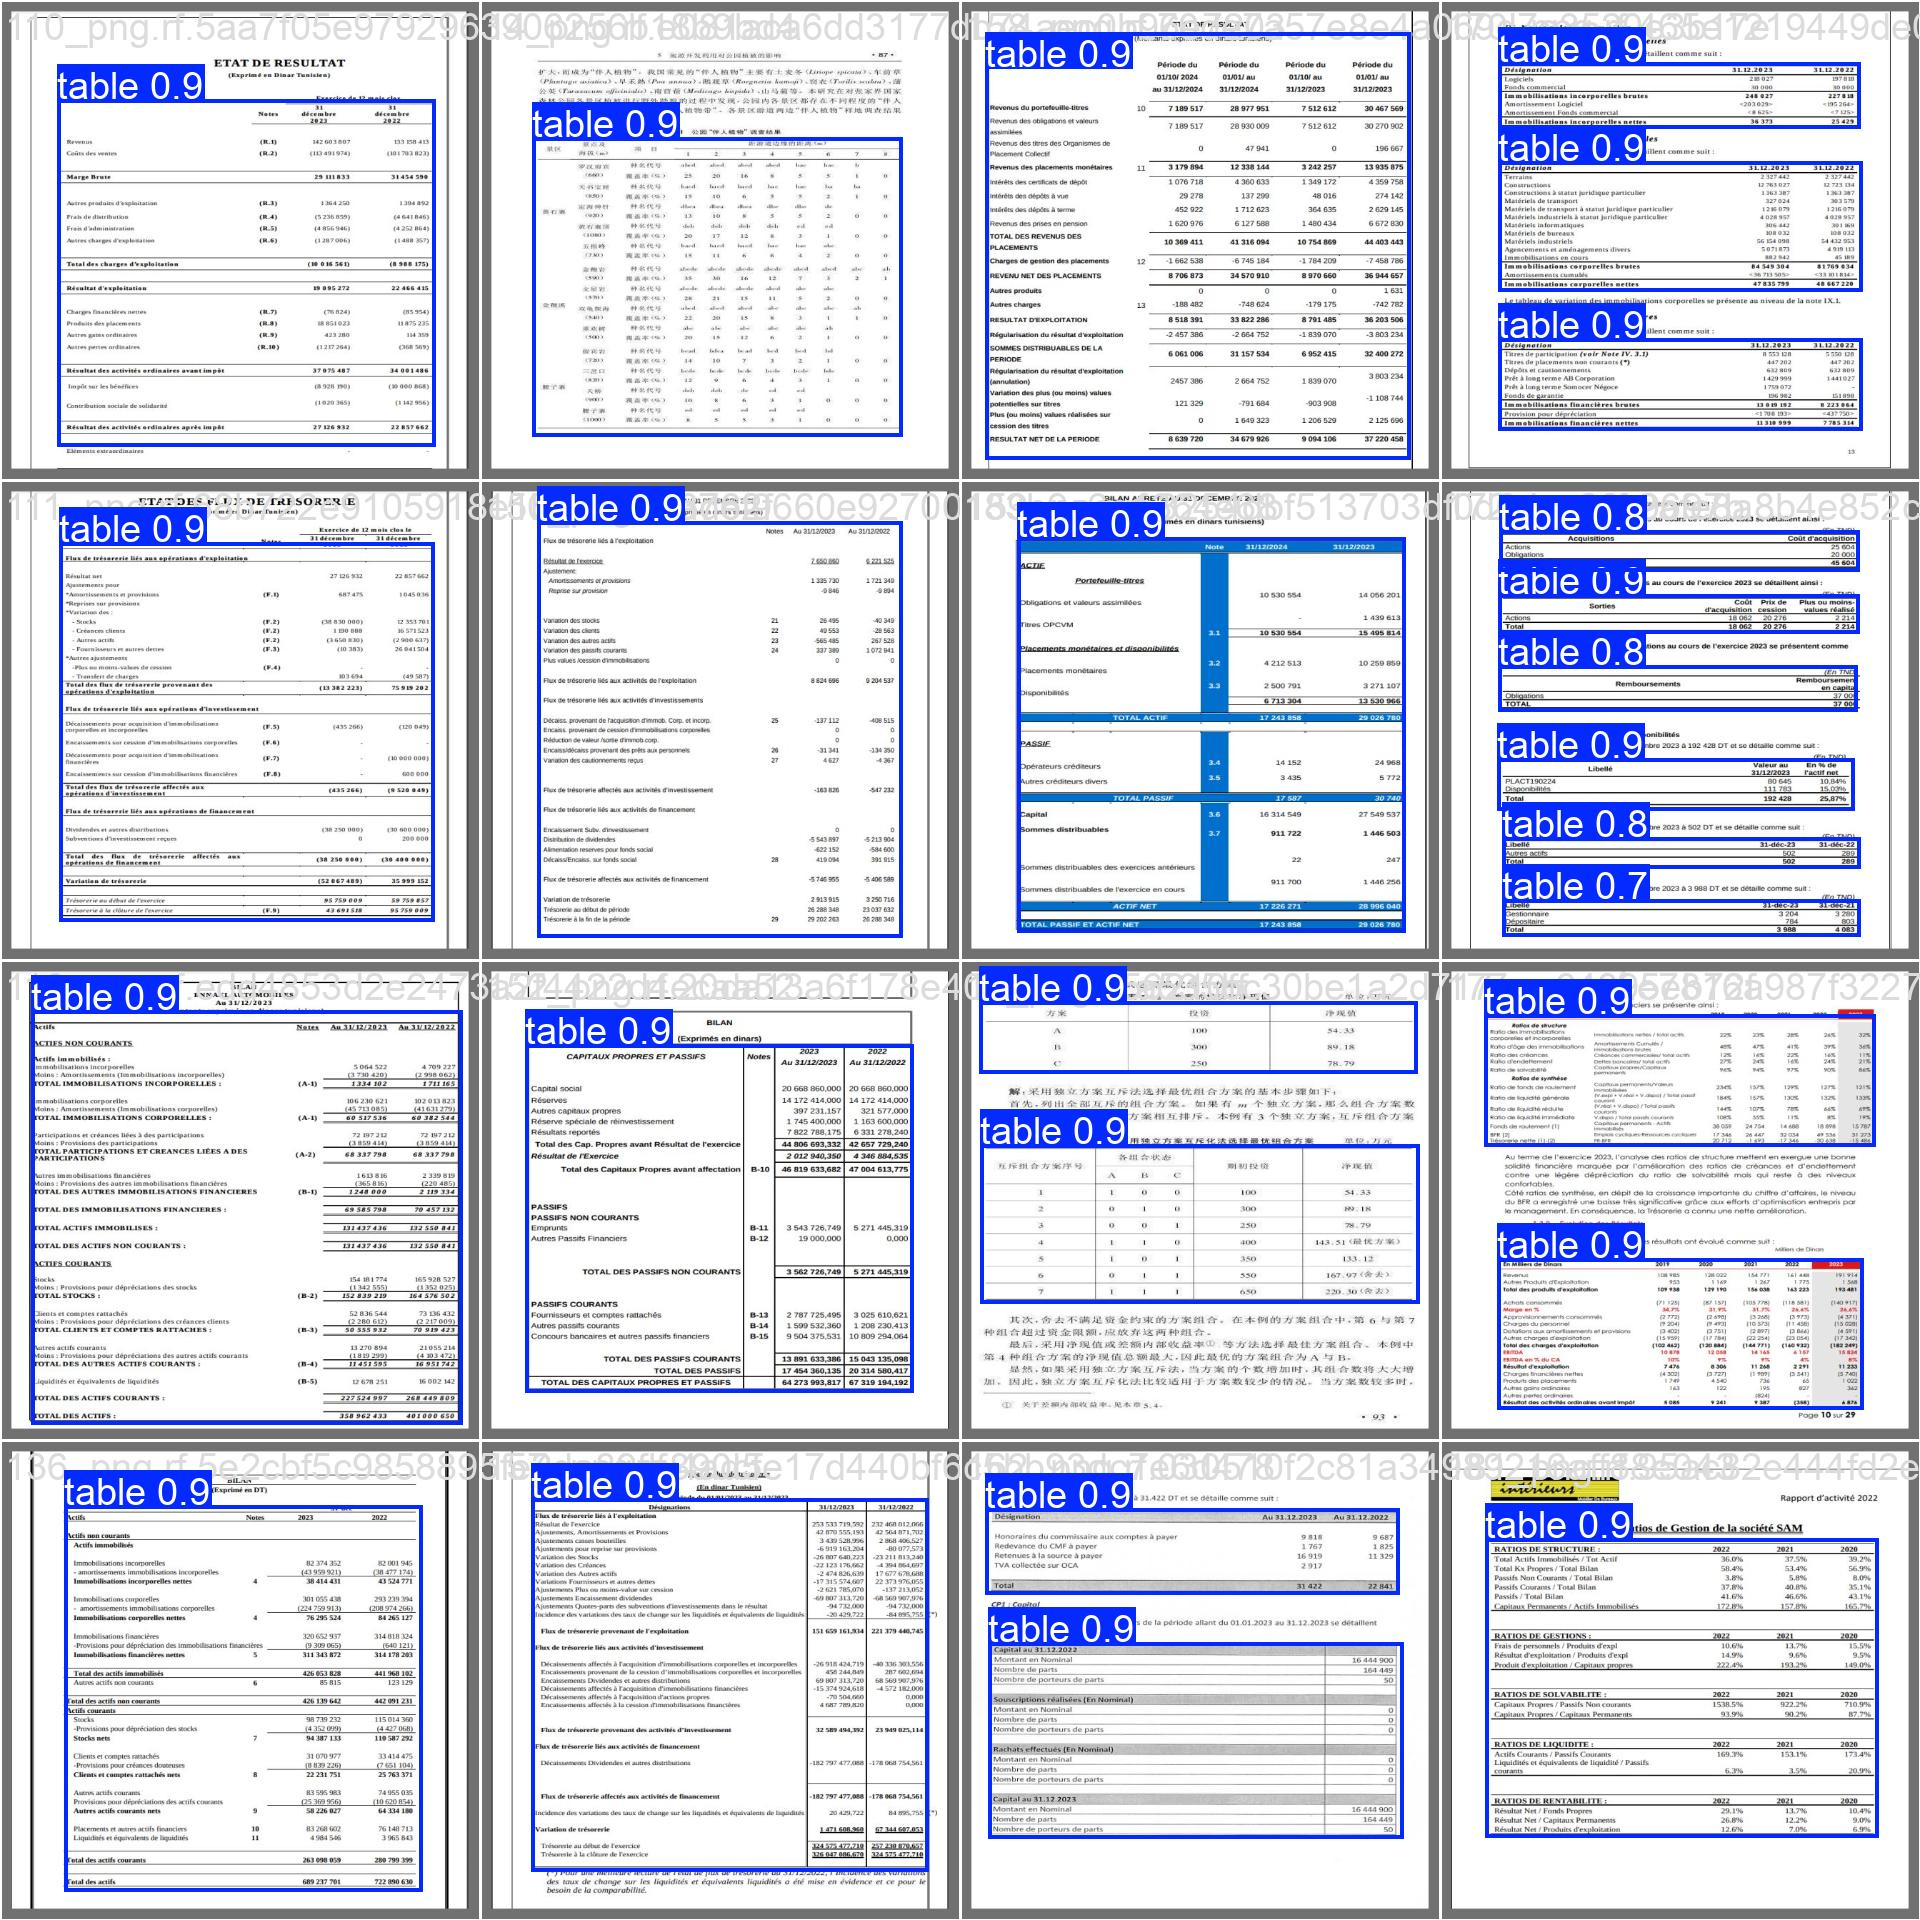

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/finance-3/valid/labels.cache... 58 images, 2 backgrounds, 0 corrupt: 100% 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 4/4 [00:02<00:00,  1.82it/s]
                   all         58        107      0.991      0.989      0.993      0.947
Speed: 5.5ms preprocess, 12.9ms inference, 0.1ms loss, 3.9ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/29 /content/datasets/finance-3/test/images/102_png.rf.bfe9c1e747eac576f49eb406dc819c42.jpg: 640x640 1 table, 15.6ms
image 2/29 /content/datasets/finance-3/test/images/103_png.rf.8a20192a38b378d4045e44eb952a8a14.jpg: 640x640 1 table, 15.6ms
image 3/29 /content/datasets/finance-3/test/images/108_png.rf.3f3c585fa180c3f834ea09ed3653231b.jpg: 640x640 1 table, 15.6ms
image 4/29 /content/datasets/finance-3/test/images/112_png.rf.299c84252aec68b7053f5dee04ecf52e.jpg: 640x640 1 table, 15.6ms
image 5/29 /content/datasets/finance-3/test/images/118_png.rf.f42a8b4c6fe68e26f1e3646780cca520.jpg: 640x640 1 table, 15.6ms
image 6/29 /content/datasets/finance-3/test/images/12_png.rf.235ac324cae310a6f9d2e0b483be2343.jpg: 640x640 1 table, 15.6ms
image 7/29 /content/datasets/finance-3/test/images/132_png.rf.9f4a3c0e026bdab61e1f6564fad7

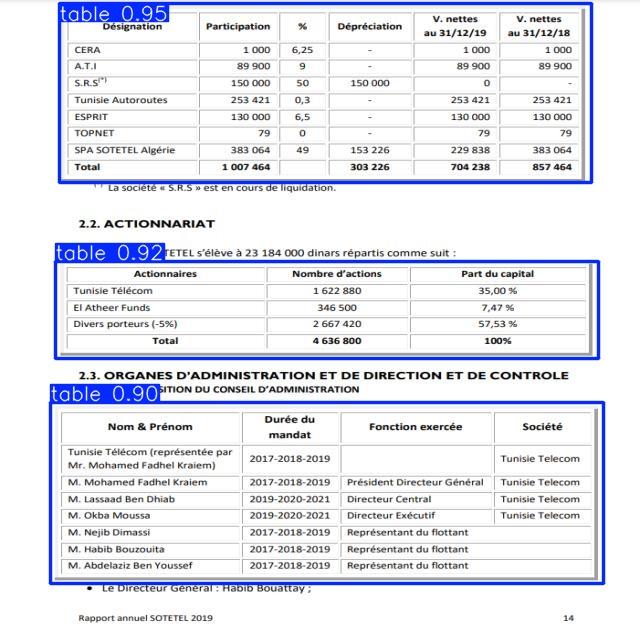

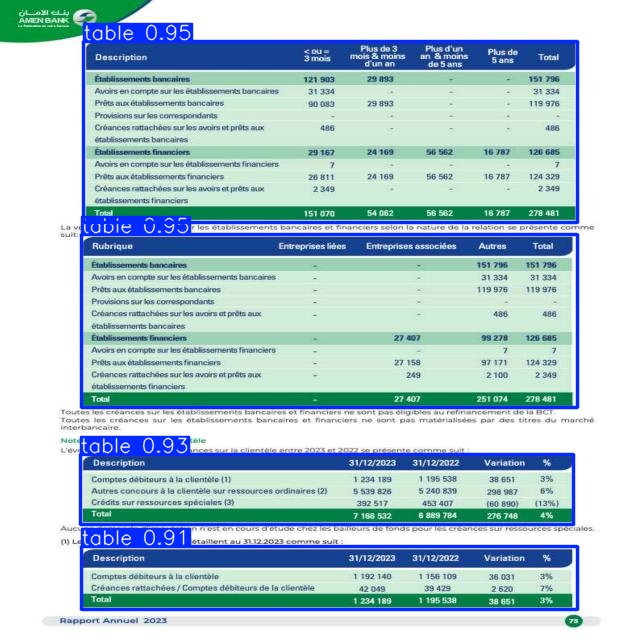

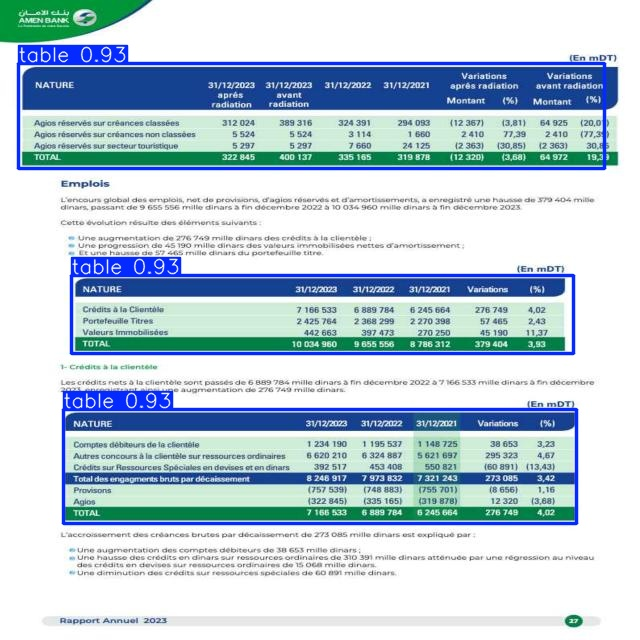

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
import cv2

In [ ]:
def extract_tables(image_path, output_dir="extracted_tables"):
    os.makedirs(output_dir, exist_ok=True)

    # Charger le modèle YOLO entraîné
    model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

    # Lire l'image originale
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # Détection avec YOLO
    results = model(img)

    extracted_paths = []

    for i, result in enumerate(results):
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()

        for j, (box, conf) in enumerate(zip(boxes, confidences)):
            if conf > 0.7:  # Seuil de confiance
                x1, y1, x2, y2 = map(int, box[:4])

                # Ajouter une marge de 10 pixels
                margin = 10
                x1 = max(0, x1 - margin)
                y1 = max(0, y1 - margin)
                x2 = min(w, x2 + margin)
                y2 = min(h, y2 + margin)

                # Découpage et sauvegarde
                table_roi = img[y1:y2, x1:x2]
                output_path = os.path.join(output_dir, f"table_{i}_{j}.jpg")
                cv2.imwrite(output_path, table_roi)
                extracted_paths.append(output_path)

    return extracted_paths

In [ ]:
from paddleocr import PaddleOCR

No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md


In [ ]:
!pip install paddleocr paddlepaddle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.4 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=bdb2f52216e52587c5a03e1073af6673134969023edb24887bb95b49f8b9f427
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire
  Attempting uninstall: opt_einsum
    Found e

In [ ]:
def analyze_table_structure(table_image_path):
    # Initialiser PaddleOCR
    ocr = PaddleOCR(use_angle_cls=True, lang='fr', show_log=False)

    # Lire l'image
    img = cv2.imread(table_image_path)

    # OCR avec analyse structurelle
    result = ocr.ocr(img, cls=True)

    # Organiser les résultats par lignes/colonnes
    lines = {}
    for line in result:
        for word_info in line:
            text = word_info[1][0]
            position = word_info[0]
            center_y = sum([point[1] for point in position])/4

            # Regroupement par ligne (alignement vertical)
            line_key = round(center_y/10)*10
            if line_key not in lines:
                lines[line_key] = []
            lines[line_key].append((text, position))

    # Trier les lignes et mots
    sorted_lines = sorted(lines.items(), key=lambda x: x[0])
    structured_data = []

    for y, words in sorted_lines:
        # Trier les mots de gauche à droite
        sorted_words = sorted(words, key=lambda x: x[1][0][0])
        line_texts = [word[0] for word in sorted_words]
        structured_data.append(line_texts)

    return structured_data

In [ ]:
# --- Ajoutez ces imports au début de votre notebook ---
from ultralytics import YOLO
import glob


0: 640x640 2 tables, 15.6ms
Speed: 3.2ms preprocess, 15.6ms inference, 138.8ms postprocess per image at shape (1, 3, 640, 640)

Analyse du tableau : extracted_tables/table_0_0.jpg
download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:16<00:00, 241.54it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/latin_PP-OCRv3_rec_infer.tar to /root/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer/latin_PP-OCRv3_rec_infer.tar


100%|██████████| 9930/9930 [00:18<00:00, 537.47it/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:14<00:00, 144.92it/s]


Libelle | 2024 | 2Z22 | Variation | %
Comptes.courants debiteurs | 952117 | 1.046606 | (94 489) | 9.0%
Credits sur ressources spéciales | 211363 | (1465) | (0.7%)
Les creances prises en charge par l'Etat | 1185 | 9440 | (552 8) | 87,4%
Bonification prise en charge par I'Etat | 4230 | 4230
Comptes courants associes | 89770
10431804 | 10777476 | 3,2%
Autres concours a la clientele
Creances abandonner | 4298 | 4298
Crcances rattachees | 75023 | 90606 | (15883) | (37,5%)
Total brut | 11769790 | 12235554 | (465.764) | (3,8%
Provisions | (1224037) | (1165 538) | 58499) | 5.0%
Provisions sur comptes courants | (150456) | (149 429) | (201) | (0,7%)
Provisions sur rexsources speciates | (54.518) | (42127) | (12391) | (29,4%)
Provisions sur autres concours  la clientele | (782792) | (719 189) | (09€9) | 8,8%)
Provisions sur comptes courants associes | 45552) | (45552)
Provisions sur creances  abandonner | (455) | (455)
Provisions collectives | (190.264) | (208786 | 18522 | 8,9%
Agios reserves | 

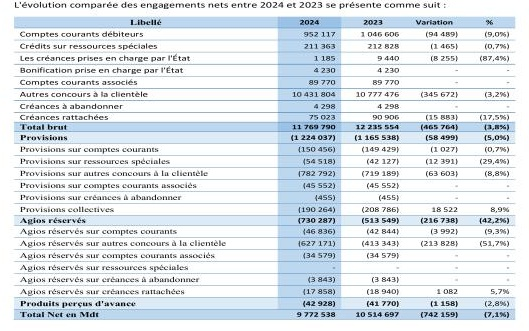


Analyse du tableau : extracted_tables/table_0_1.jpg
Libelle | 2ZO2 | Dotations | Reprises | Reclass | 2024
Provisions pour risgues divers (Creances sur les
etablissements bancaires | 23247 | 1092 | 24339
23247
Total | 1092 | 24339


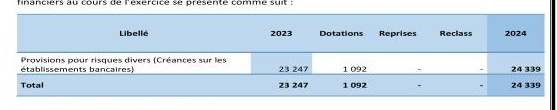

In [ ]:
# --- 9. Exécution du Pipeline Complet ---
# Exemple pour une image de test
test_image = glob.glob(f'{dataset.location}/test/images/*.jpg')[3]
extracted_tables = extract_tables(test_image)
#display(IPyImage(extracted_tables, width=600))

for table_path in extracted_tables:
    print(f"\nAnalyse du tableau : {table_path}")
    table_data = analyze_table_structure(table_path)

    # Affichage des données structurées
    for row in table_data:
        print(" | ".join(row))

    # Afficher l'image du tableau extrait
    display(IPyImage(filename=table_path, width=600))

In [ ]:
!pip install pdf2image

In [ ]:
from pdf2image import convert_from_path

In [ ]:
!apt-get install -y poppler-utils


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.8 [186 kB]
Fetched 186 kB in 0s (2,215 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 126102 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.8_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.8) ...
Setting up poppler-utils (22.02.0-2ubuntu0.8) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
from pdf2image import convert_from_path
pdf_path = "/content/sotumag.pdf"

# #collect images from the pdf
images = convert_from_path(pdf_path, dpi=300)
for i, image in enumerate(images):
    image.save(f"page_{i+1}.png", "PNG")

In [ ]:
import os
import glob

# Chemin vers les images générées
folder_path = "/content"  # à adapter selon ton cas
images = glob.glob(os.path.join(folder_path, "page_*.png"))

for image_path in images:
    os.remove(image_path)
    print(f"Supprimé : {image_path}")


Supprimé : /content/page_13.png
Supprimé : /content/page_12.png
Supprimé : /content/page_17.png
Supprimé : /content/page_3.png
Supprimé : /content/page_6.png
Supprimé : /content/page_10.png
Supprimé : /content/page_9.png
Supprimé : /content/page_1.png
Supprimé : /content/page_11.png
Supprimé : /content/page_5.png
Supprimé : /content/page_7.png
Supprimé : /content/page_4.png
Supprimé : /content/page_18.png
Supprimé : /content/page_15.png
Supprimé : /content/page_2.png
Supprimé : /content/page_14.png
Supprimé : /content/page_16.png
Supprimé : /content/page_8.png
